---
---
# Scifate Demo: Single-Cell RNA Dynamics with `sciflow`

This notebook demonstrates how to load, structure, inspect and analyze a Scifate-style single-cell RNA dataset using the `sciflow` package.


--- 

## Table of Contents

<div style="font-size: 1.15em; line-height: 1.6;">

1. <a href="#1-introduction"><b>Introduction</b></a>  
2. <a href="#2-what-is-scifate"><b>What is Scifate?</b></a>  
3. <a href="#3-loading-the-data"><b>Loading the Data</b></a>  
4. <a href="#4-working-with-the-dataset"><b>Inspecting the Dataset</b></a>  

</div>



---
---

In [1]:
%matplotlib widget

# std lib imports
import time
import math

# 3-party import
import pandas as pd
import numpy as np

# projekt imports
from sciflow.data.scifate_dataset import ScifateDataLoader, ScifateDataset
from sciflow.data import LabeledSparseMatrix, LabeledDistanceMatrix, Dataset

---
---

## 1. Introduction


The goal of this notebook is to demonstrate how `sciflow` handles biological high-dimensional data.






---
---

## 2. What is Scifate?


---
---

## 3. Loading the Data

In the following section, the different data structures used for handling and organizing the dataset are introduced.

--- 

### Data Structures

The package is built around three core data structures:

#### `Dataset`

The `Dataset` class represents the general high-level container for structured datasets.

It stores:

- the underlying data matrix
- sample metadata (`sample_info`)
- feature metadata (`feature_info`)
- dataset-level information such as the dataset name

The class provides a unified interface for accessing dataset dimensions and general dataset properties.


#### `LabeledSparseMatrix`

The `LabeledSparseMatrix` is the central structure used for handling high-dimensional sparse data efficiently.

It combines:

- a sparse matrix representation
- row metadata
- column metadata
- label-aware indexing and filtering

The object supports:

- view-based subsetting without duplicating the underlying matrix
- efficient sparse storage
- metadata-based filtering
- row/column selection
- labeled matrix export as pandas DataFrames

This structure is especially useful for single-cell datasets where matrices are extremely sparse and strongly coupled with metadata.


#### `ScifateDataset`

The `ScifateDataset` extends the generic `Dataset` class and represents a dataset specifically tailored to the SciFate format.

It combines:

- the expression matrix
- optional NTR/RNA dynamics information
- cell metadata
- gene metadata
- trajectory information

The dataset internally uses `LabeledSparseMatrix` objects to store both expression and NTR matrices together with 
their corresponding annotations. This provides a convenient interface for working with biological high-dimensional 
data while keeping sparse operations memory efficient.

---

### Using the `ScifateDataLoader`

To work with a `ScifateDataset`, we use the `ScifateDataLoader` that is responsible for:

- locating the required dataset files  
- reading them from disk  
- ensuring consistent dimensions  
- transforming all matrices into a unified format  
- constructing a structured `ScifateDataset` object  

In [2]:
scifate_loader = ScifateDataLoader()

**Option 1 — Load from folder**

In [3]:
scifate_data = scifate_loader.load(folder_path="/home/nicolas/code/master/higdim/HighDim/data/ScifateData")

**Option 2 — Load from individual files**

In [4]:
scifate_data_ = scifate_loader.load(
    expression_matrix_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/matrix.mtx",
    ntr_matrix_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/4sU.Binom.ntr.mtx",
    barcodes_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/barcodes.tsv",
    features_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/features.tsv",
    trajectories_path="/home/nicolas/code/master/higdim/HighDim//data/ScifateData/trajectories_sci.csv",
)

Avter we loaded the dataset we can look at the summary to see that everything worked fine.

In [5]:
print(scifate_data.summary())

ScifateDataset(
  name = SciFateDataset,
  shape = 7404 cells x 43750 genes,
  ntr = yes,
  cell_info = yes,
  gene_info = yes
  trajectory = yes
)


---
---

## 4. Working with the Dataset

After loading the dataset, the expression matrix, NTR matrix, and metadata can be accessed directly. The expression_matrix and the ntr_matrix are `LabeledSparseMatrix` objects.
The Gene Info and the Cell Info will be `pandas.Dataframes` that contain multible features that represent infos about the rows and columns of the NTR matrix and expression Matrix.




---

### Inspecting the data within the dataset 

In [6]:
# let's look at the gene info (info about the columns of the ntr and expression matrix)
scifate_data.gene_info.head()

,gene_id,gene_name,feature_type,region,length
0,ENSG00000225602,MTOR-AS1,Gene Expression,Exonic (h.ens90),705
1,ENSG00000171819,ANGPTL7,Gene Expression,Exonic (h.ens90),2238
2,ENSG00000238173,RPL39P6,Gene Expression,Exonic (h.ens90),150
3,ENSG00000239149,SNORA59A,Gene Expression,Exonic (h.ens90),152
4,ENSG00000204518,AADACL4,Gene Expression,Exonic (h.ens90),1575


In [7]:
# let's look at the cell info (info about the rows of the ntr and expression matrix)
scifate_data.cell_info.head()

,barcode,cell_line,time,cell_barcode
0,A549.4h.AAAAACTCTCTCAA,A549,4h,AAAAACTCTCTCAA
1,A549.6h.AAAAAAGAAGTTCA,A549,6h,AAAAAAGAAGTTCA
2,A549.8h.AAAAACGGAGAATA,A549,8h,AAAAACGGAGAATA
3,A549.4h.AAAACGATCCTGGA,A549,4h,AAAACGATCCTGGA
4,A549.6h.AAAAACTGAATTCC,A549,6h,AAAAACTGAATTCC


We can also look and work with the expression_matrix and the NTR matrix in a sparse form and also in a rendered full matrix form.

In [8]:
print(scifate_data.expression_matrix.matrix_sparse[30:60, 30:60])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (30, 30)>
  Coords	Values
  (1, 26)	1
  (4, 7)	1
  (25, 20)	1


In [9]:
print(scifate_data.expression_matrix.head(n = 5))

                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.4h.AAAAACTCTCTCAA         0        0        0         0        0
A549.6h.AAAAAAGAAGTTCA         0        0        0         0        0
A549.8h.AAAAACGGAGAATA         0        0        0         0        0
A549.4h.AAAACGATCCTGGA         0        0        0         0        0
A549.6h.AAAAACTGAATTCC         0        0        0         0        0


In [10]:
print(scifate_data.expression_matrix.summary())

LabeledSparseMatrix(
  name=expression_matrix,
  shape=(7404, 43750),
  dtype=int64,
  not_zero=43838929,
  density=13.5337%,
  is_view=True,
  row_info=['barcode', 'cell_line', 'time', 'cell_barcode'],
  col_info=['gene_id', 'gene_name', 'feature_type', 'region', 'length']
)


---
### Working with the data within the dataset 
Because both expression_matrix and ntr_matrix are `LabeledSparseMatrix` objects we can select data by rows and columns to get a new view on the sparse matrix with that we can work.

In [11]:
expression_matrix = scifate_data.expression_matrix

print(f"Type of expression_matrix: {type(expression_matrix)}")

# selecting diverent properties from the expression matrix
expression_4h = expression_matrix.select_rows(time="4h")

print(f"Type of expression_4h: {type(expression_4h)}")

print()
print(f"Expression Matrix 4h {expression_4h.shape} head:")
print(expression_4h.head(5))

Type of expression_matrix: <class 'sciflow.data.labled_sparse_matrix.LabeledSparseMatrix'>
Type of expression_4h: <class 'sciflow.data.labled_sparse_matrix.LabeledSparseMatrix'>

Expression Matrix 4h (1045, 43750) head:
                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.4h.AAAAACTCTCTCAA         0        0        0         0        0
A549.4h.AAAACGATCCTGGA         0        0        0         0        0
A549.4h.AAAAATAAGAGGCG         0        0        0         0        0
A549.4h.AAAAGAATCGACGT         0        0        0         0        0
A549.4h.AAAAACTAATTGAG         0        0        0         0        0


Because we get a "new" `LabeledSparseMatrix` from the select we can select even further or chain selection operations.

In [12]:
expression_4h_cells = expression_matrix.select_rows(cell_barcode=["AAAAACTCTCTCAA", "AAAACGATCCTGGA", "AAAAATAAGAGGCG"]).select_cols(gene_id=["ENSG00000225602", "ENSG00000171819", "ENSG00000238173"])

print(expression_4h_cells)

                        MTOR-AS1  ANGPTL7  RPL39P6
A549.4h.AAAAACTCTCTCAA         0        0        0
A549.4h.AAAACGATCCTGGA         0        0        0
A549.4h.AAAAATAAGAGGCG         0        0        0


Now we have three diverent `LabeledSparseMatrix` but we dont save the matrix and the infos in all of them the selected ones will just be a view of the original  `LabeledSparseMatrix` 

In [13]:
print(f"Same object:                {id(expression_matrix) == id(expression_4h) == id(expression_4h_cells)}")
print("-" * 35)
print(f"Shared matrix object:       {id(expression_matrix._matrix) == id(expression_4h._matrix) == id(expression_4h_cells._matrix)}")
print(f"Shared row_info object:     {id(expression_matrix._row_info) == id(expression_4h._row_info) == id(expression_4h_cells._row_info)}")
print(f"Shared col_info object:     {id(expression_matrix._col_info) == id(expression_4h._col_info) == id(expression_4h_cells._col_info)}")

Same object:                False
-----------------------------------
Shared matrix object:       True
Shared row_info object:     True
Shared col_info object:     True


---
#### Numpy-like indexing

The `LabeledSparseMatrix` also suports NumPy-like indexing. The returned object is again a `LabeledSparseMatrix`, allowing chained selections and preserving all metadata.

In [14]:
# Select a single element
expression_matrix_entery = scifate_data.expression_matrix[100,100]

print(expression_matrix_entery)

                        TUBB8P11
A549.0h.CTACCCTGCATCAA         0


In [15]:
# Select a single row
expression_matrix_column = scifate_data.expression_matrix[100,:].head(5)

print(expression_matrix_column)

                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.0h.CTACCCTGCATCAA         0        0        0         0        0


In [16]:
# Select a single column
expression_matrix_column = scifate_data.expression_matrix[:,10].head(7)

print(expression_matrix_column)

                         PRAMEF12
A549.4h.AAAAACTCTCTCAA          0
A549.6h.AAAAAAGAAGTTCA          0
A549.8h.AAAAACGGAGAATA          0
A549.4h.AAAACGATCCTGGA          0
A549.6h.AAAAACTGAATTCC          0
A549.2h.AAAAGCCATCAACT          0
A549.10h.AAAATTGAGTATCA         0


In [17]:
# Select with a bolen mask 
mask = (scifate_data.expression_matrix.row_info["time"] == "4h")
expression_matrix_4h = scifate_data.expression_matrix[mask, :]

print(expression_matrix_4h.head(5))

                        MTOR-AS1  ANGPTL7  RPL39P6  SNORA59A  AADACL4
A549.4h.AAAAACTCTCTCAA         0        0        0         0        0
A549.4h.AAAACGATCCTGGA         0        0        0         0        0
A549.4h.AAAAATAAGAGGCG         0        0        0         0        0
A549.4h.AAAAGAATCGACGT         0        0        0         0        0
A549.4h.AAAAACTAATTGAG         0        0        0         0        0


--- 

#### Working with trajectories

Besides the expression and NTR matrices, the dataset also contains trajectory information describing temporal relationships between cells across different time points.
These trajectories can be used to directly extract and analyze dynamic expression patterns over time.

In [18]:
print(f"Barcode (A549.6h.GCGAGGCCTCCATT) is in trajectory with id: {scifate_data.get_trajectory_id(barcode="A549.6h.GCGAGGCCTCCATT")}")

Barcode (A549.6h.GCGAGGCCTCCATT) is in trajectory with id: 5


In [19]:
scifate_data.get_trajectory_expression(trajectory_id=5).head(5)

,MTOR-AS1,ANGPTL7,RPL39P6,SNORA59A,AADACL4
A549.8h.AAACAACTACCGAC,0,0,0,0,0
A549.10h.ACCTGGTCCAGGAG,0,0,0,0,0
A549.0h.CTGTAGGTCTATGG,0,0,0,0,0
A549.6h.GCGAGGCCTCCATT,0,0,0,0,0
A549.4h.GCGGATCCTACCTC,0,0,0,0,0


In [20]:
scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC").head(5)

,MTOR-AS1,ANGPTL7,RPL39P6,SNORA59A,AADACL4
A549.8h.AAACAACTACCGAC,0,0,0,0,0
A549.10h.ACCTGGTCCAGGAG,0,0,0,0,0
A549.0h.CTGTAGGTCTATGG,0,0,0,0,0
A549.6h.GCGAGGCCTCCATT,0,0,0,0,0
A549.4h.GCGGATCCTACCTC,0,0,0,0,0


--- 

#### Working with new RNA


In [21]:
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                         # This will give us 5 Cells with each 40k genes
ntr_cells = scifate_data.get_trajectory_ntr(barcode="A549.4h.GCGGATCCTACCTC")                                       # this will give us the new to total ratio for the same 5 cells for all 40k genes         

new_rna = expression_cells * ntr_cells                                                                              # calculating the new_rna per time step for the 5 cells

new_rna[:, 190:195]                                                                                                

                         FAM76A  AL161638.1  MATN1-AS1  LINC01778   PNRC2
A549.8h.AAACAACTACCGAC      0.0         0.0        0.0        0.0  0.0000
A549.10h.ACCTGGTCCAGGAG     0.0         0.0        0.0        0.0  0.0000
A549.0h.CTGTAGGTCTATGG      0.0         0.0        0.0        0.0  0.0000
A549.6h.GCGAGGCCTCCATT      1.0         0.0        0.0        0.0  0.0000
A549.4h.GCGGATCCTACCTC      0.0         0.0        0.0        0.0  1.0000
A549.2h.ATCTATCTAGGTTC      0.0         0.0        0.0        0.0  2.0805

--- 

#### Working with old RNA


In [22]:
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                         # This will give us 5 Cells with each 40k genes
ntr_cells = scifate_data.get_trajectory_ntr(barcode="A549.4h.GCGGATCCTACCTC")                                       # this will give us the new to total ratio for the same 5 cells for all 40k genes         

old_rna = expression_cells - (expression_cells * ntr_cells)                                                         # calculating the new_rna per time step for the 5 cells

print(old_rna[ : , 190 : 195])                                                                                      # print cols where something is :D

                         FAM76A  AL161638.1  MATN1-AS1  LINC01778   PNRC2
A549.8h.AAACAACTACCGAC      0.0         0.0        0.0        0.0  0.0000
A549.10h.ACCTGGTCCAGGAG     0.0         0.0        0.0        0.0  0.0000
A549.0h.CTGTAGGTCTATGG      0.0         0.0        0.0        0.0  0.0000
A549.6h.GCGAGGCCTCCATT      0.0         0.0        0.0        0.0  0.0000
A549.4h.GCGGATCCTACCTC      0.0         0.0        0.0        0.0  0.0000
A549.2h.ATCTATCTAGGTTC      1.0         0.0        0.0        0.0  0.9195


---
---
## 4. Distances and Heatmaps on parts of the data

---

### Distance Metrics

Different biological questions often require different notions of similarity. The package therefore provides multiple interchangeable distance metrics built on top of a shared `BaseDistance` interface.


# TODO

--- 
#### The two distances used in the following are:

##### <span style="color:lightgreen">1. Cosine Distance</span>
Instead of comparing absolute magnitudes, it compares the **direction** of two expression vectors:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $d_{\text{cos}}(x, y)=1 -\frac{x^\top y}{\|x\|\|y\|}$


##### <span style="color:lightgreen">2. Correlation Distance</span>
Correlation distance compares the **relative variation structure** between vectors:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $d_{\text{corr}}(x, y) = 1 - \frac{(x - \bar{x})^\top (y - \bar{y})}{\|x - \bar{x}\| \, \|y - \bar{y}\|}$

Instead of absolute expression values, it focuses on up/down regulation patterns and the relative feature behavior.
Because centering destroys sparsity, correlation distance internally operates on dense representations.


##### <span style="color:lightgreen">3. Manhattan Distance</span>
Manhattan distance measures the absolute element-wise differences between two vectors:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $d_{\text{man}}(x, y)=\sum_i |x_i-y_i|$

Instead of considering vector direction or correlation structure, Manhattan distance directly accumulates the absolute differences across all features.
This makes it sensitive to magnitude changes while often being more robust to outliers than Euclidean distance.
In the context of gene expression data, Manhattan distance reflects the total absolute transcriptional difference between two cells or genes across all measured features.

---

In [23]:
from sciflow.distance import CorrelationDistance, CosineDistance, ManhattanDistance, EuclideanDistance

---
### Calculating and Visualizing the Distance Matrices



Internally, the rows are always interpreted as data points and the columns as features. 

For example:

- cell distances:
  rows = cells, columns = genes

- gene distances:
  rows = genes, columns = cells

- trajectory distances:
  rows = trajectories, columns = concatenated trajectory features

The resulting distance matrices are stored as `LabeledDistanceMatrix` objects and can optionally be cached inside the dataset for later reuse.

In [24]:
from sciflow.plotting.scifate_plotter import ScifatePlotter

plotter = ScifatePlotter(dataset=scifate_data)

---
##### <span style="color:lightblue">1. Distance Matrix of Cells Along a Single Trajectory</span>


One of the first ways to analyze and better understand the scifate data is to investigate the similarity between different cells. Instead of directly analyzing thousands of individual genes, we can compare entire gene expression profiles between cells and quantify how similar or dissimilar they are to each other. This allows us to identify whether cells share similar transcriptional states, belong to related biological conditions, or follow common developmental processes. To achieve this, pairwise distances between cells can be computed based on their gene expression profiles. The resulting distance matrix provides a compact representation of the relationships between all cells in the dataset and forms the basis for further analyses such as clustering, trajectory validation, and visualization of temporal progression.

In [25]:
# Calculate the distance betweean diverent cells from the same trajectory
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                                 # This will give us 5 Cells with each 40k genes

cells_dist_matrix = scifate_data.create_distance_matrix(matrix=expression_cells, distance=CorrelationDistance(), entity="cell", data="expression", save=True)

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 192.17it/s]


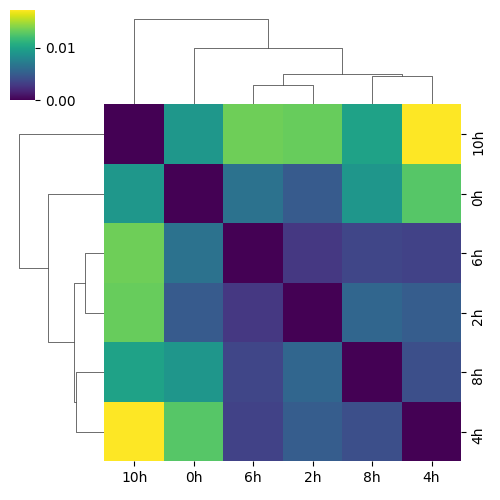

In [26]:
cells_dist_matrix.row_label, cells_dist_matrix.col_label = "time", "time"   

fig =  plotter.plot_distance_matrix(dist_matrix=cells_dist_matrix, cluster_cols=True, figsize=(5,5))

The hierarchical clustering reorganizes the rows and columns such that transcriptionally similar cells are placed next to each other.  
The dendrogram therefore visualizes the similarity structure of the trajectory and reveals which time points cluster together based on their global gene expression behavior.

In this example, neighboring time points tend to show smaller distances, indicating a gradual temporal progression of the cellular state along the trajectory.

---
##### <span style="color:lightblue">2. Distance Matrix of Different Genes</span>

Besides comparing cells, it is also possible to investigate the similarity between genes themselves. Instead of treating cells as observations, the expression profiles of genes across multiple cells are compared to identify genes that exhibit similar transcriptional behavior. Genes with small distances show similar expression patterns across the analyzed cells, which may indicate shared biological functions, co-regulation, or participation in common cellular pathways. In contrast, genes with larger distances behave more independently and may be associated with different biological processes. By computing pairwise distances between genes, the resulting distance matrix captures the global relationship structure between all analyzed genes. Such matrices are useful for identifying groups of co-expressed genes, exploring transcriptional programs, and detecting potential functional relationships between genes.

In [27]:
# Calculate the distance betweean diverent genes
expression_genes = scifate_data.expression_matrix[:, [10,20,30,40,50,60]].T                                                                 # here we need to transpose the matrix because we always    
genes_dist_matrix = scifate_data.create_distance_matrix(matrix=expression_genes, distance=ManhattanDistance())

ManhattanDistance: 100%|██████████| 1/1 [00:00<00:00, 999.36it/s]


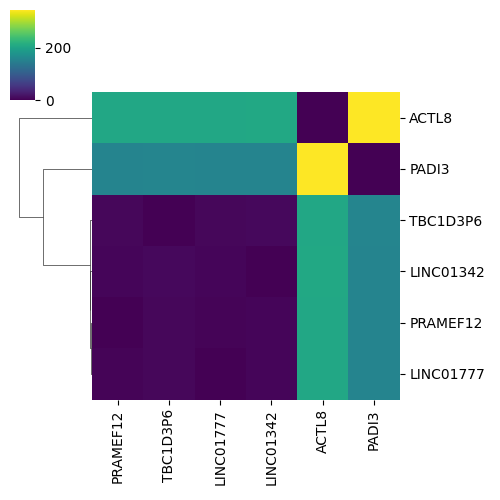

In [28]:
fig = plotter.plot_distance_matrix(dist_matrix=genes_dist_matrix, cluster_rows=True, figsize=(5,5))

---
##### <span style="color:lightblue">3. Distance Matrix of Different Trajectories</span>

Beyond comparing individual cells or genes, entire trajectories can also be compared with each other. In this setting, each trajectory represents a temporal sequence of cellular states, and the distance matrix measures how similar or dissimilar these overall developmental patterns are. Trajectories with small distances exhibit similar transcriptional dynamics over time, suggesting that they may follow related biological processes or cellular responses. Larger distances indicate stronger differences in temporal gene expression behavior and may point to distinct biological pathways or developmental programs. To compute trajectory-level distances, the expression information of all cells belonging to a trajectory is aggregated into a trajectory representation vector. Pairwise distances between these vectors then provide a compact summary of the relationships between complete trajectories. The resulting distance matrix enables the identification of groups of trajectories with similar temporal behavior and helps to reveal higher-level structures within the dataset.

In [29]:
# Calculate the distance berwean diveren trajectorys 
trajectory_dist_matrix = scifate_data.create_distance_matrix(entity="trajectory", data="expression", distance=CosineDistance())[:20, :20]

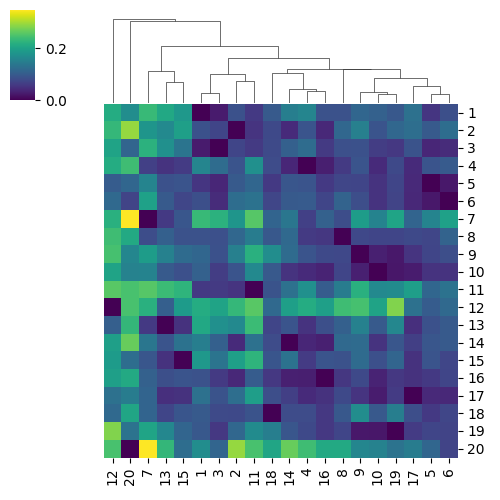

In [39]:
fig =  plotter.plot_distance_matrix(dist_matrix=trajectory_dist_matrix, cluster_cols=True, cluster_rows=False, figsize=(5,5))

---
##### <span style="color:lightblue">4. Distance Matrix of Cells New RNA</span>

Besides analyzing total gene expression, it is also possible to specifically investigate the similarity between cells based only on newly transcribed RNA. Instead of using the complete expression profiles, the expression counts are weighted by the NTR (new-to-total RNA ratio), resulting in an approximation of the newly synthesized RNA for each gene and cell. This representation focuses on active and recent transcriptional activity rather than accumulated total RNA abundance. As a result, the corresponding distance matrix captures similarities in ongoing gene regulation and dynamic cellular responses. Cells with small distances therefore exhibit similar patterns of newly produced RNA, suggesting comparable current transcriptional programs or biological activity. Larger distances indicate stronger differences in active transcriptional behavior between cells. The clustered distance matrix can help reveal dynamic transcriptional transitions that may not be as visible in the total expression matrix alone.

In [31]:
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                         # This will give us 5 Cells with each 40k genes
ntr_cells = scifate_data.get_trajectory_ntr(barcode="A549.4h.GCGGATCCTACCTC")                                       # this will give us the new to total ratio for the same 5 cells for all 40k genes         

new_rna = expression_cells * ntr_cells                                                                              # calculating the new_rna per time step for the 5 cells

new_rna_dist_matrix = scifate_data.create_distance_matrix(
                                                            matrix=new_rna, 
                                                            distance=CorrelationDistance()
                                                        )

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 253.08it/s]


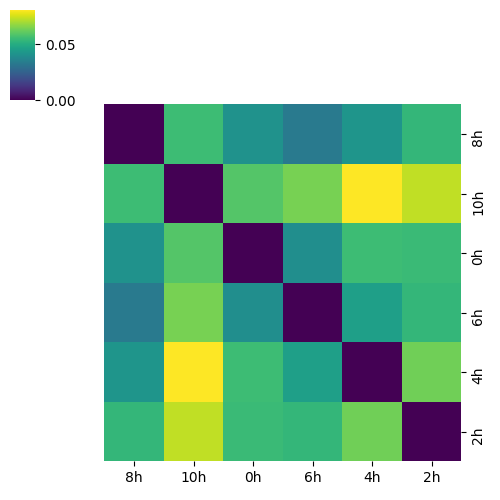

In [32]:
new_rna_dist_matrix.row_label, new_rna_dist_matrix.col_label = "time", "time"                                                                                          
fig =  plotter.plot_distance_matrix(dist_matrix=new_rna_dist_matrix, cluster_cols=False, cluster_rows=False, figsize=(5,5))

---
##### <span style="color:lightblue">5. Distance Matrix of Cells Old RNA</span>

In addition to newly synthesized RNA, similarities between cells can also be analyzed based on old RNA. Here, the newly transcribed fraction is subtracted from the total expression profile, resulting in an approximation of the remaining pre-existing RNA within each cell. While new RNA mainly reflects recent transcriptional activity, old RNA captures the more stable and accumulated transcriptional state of the cell. The corresponding distance matrix therefore emphasizes longer-term expression patterns rather than immediate transcriptional changes. Cells with small distances exhibit similar old RNA compositions, indicating comparable persistent cellular states or previously established transcriptional programs. Larger distances suggest stronger differences in the underlying accumulated RNA landscape between cells. Comparing the old RNA distance matrix with the new RNA distance matrix can provide additional biological insight into which similarities arise from stable cellular identity and which are driven by ongoing dynamic transcriptional processes.

In [33]:
expression_cells = scifate_data.get_trajectory_expression(barcode="A549.4h.GCGGATCCTACCTC")                         # This will give us 5 Cells with each 40k genes
ntr_cells = scifate_data.get_trajectory_ntr(barcode="A549.4h.GCGGATCCTACCTC")                                       # this will give us the new to total ratio for the same 5 cells for all 40k genes         

old_rna = expression_cells - (expression_cells * ntr_cells)                                                         # calculating the old_rna per time step for the 5 cells

old_rna_dist_matrix = scifate_data.create_distance_matrix(
                                                            matrix=old_rna, 
                                                            distance=CorrelationDistance(), 
                                                            entity="cell", 
                                                            data="expression", 
                                                            save=True
                                                        )

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 149.76it/s]


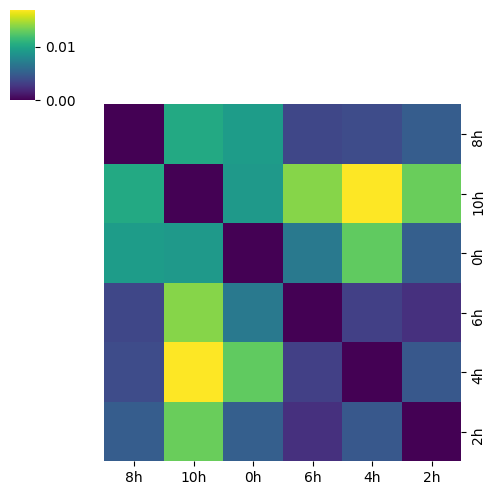

In [34]:
old_rna_dist_matrix.row_label, old_rna_dist_matrix.col_label = "time", "time"                                                                                          
fig =  plotter.plot_distance_matrix(dist_matrix=old_rna_dist_matrix, cluster_cols=False, cluster_rows=False, figsize=(5,5))

In [35]:


# new_rna_dist_matrix = scifate_data.create_distance_matrix(
#                                                             entity="cell",
#                                                             data="expression", 
#                                                             distance=CosineDistance(),
#                                                             save=True
#                                                         )

In [36]:
# new_rna_dist_matrix = scifate_data.create_distance_matrix(
#                                                             entity="cell",
#                                                             data="expression", 
#                                                             distance=CorrelationDistance(),
#                                                             save=True
#                                                         )

In [37]:

# new_rna_dist_matrix = scifate_data.create_distance_matrix(
#                                                             entity="cell",
#                                                             data="expression", 
#                                                             distance=EuclideanDistance(),
#                                                             save=True
#                                                         )

In [38]:
new_rna_dist_matrix = scifate_data.create_distance_matrix(
                                                            entity="cell",
                                                            data="expression", 
                                                            distance=ManhattanDistance(),
                                                            save=True
                                                        )

ManhattanDistance:   2%|▏         | 41/2468 [01:14<1:13:57,  1.83s/it]


KeyboardInterrupt: 

---
---
## 5. Distance Matrix on whole Data

For large single-cell datasets, directly computing distances in the original high-dimensional gene space can become computationally expensive. 

In [ ]:
import time

sample_size = 1000
sample_matrix = scifate_data.expression_matrix[:sample_size, :]

distances = [
    CorrelationDistance(),
    CosineDistance(),
    ManhattanDistance(),
]

total_cells = scifate_data.expression_matrix.n_rows
total_computations = total_cells * (total_cells - 1) // 2

print(f"Total cells: {total_cells}")
print(f"Total computations: {total_computations:,}")
print("-" * 60)

for distance in distances:

    start = time.time()

    sample_dist_matrix = scifate_data.create_distance_matrix(
        matrix=sample_matrix,
        entity="cell",
        data="expression",
        distance=distance,
        save=False
    )

    end = time.time()

    sample_time = end - start

    sample_computations = sample_size * (sample_size - 1) // 2

    time_per_computation = sample_time / sample_computations

    estimated_total_time = time_per_computation * total_computations

    print(f"Distance: {distance.name}")
    print(f"Sample size: {sample_size}")
    print(f"Sample computations: {sample_computations:,}")
    print(f"Sample time: {sample_time:.2f} seconds")
    print(f"Time per computation: {time_per_computation:.10f} seconds")
    print(f"Estimated full runtime: {estimated_total_time / 60:.2f} minutes")
    print(f"Estimated full runtime: {estimated_total_time / 3600:.2f} hours")
    print("-" * 60)


To address this, random projections can be used to project the data into a lower-dimensional space while still approximately preserving the distances between cells. Under certain conditions, the projected distances remain close to the original distances of the high-dimensional data. This makes it possible to compute distance matrices more efficiently without completely losing the geometric structure of the dataset.

One important theoretical foundation is the Johnson–Lindenstrauss lemma. It states that a set of n points can be projected into a significantly lower-dimensional space such that pairwise distances are preserved up to a small error. More formally, for an error parameter $\varepsilon \in (0, 1)$, there exists a projection into dimension:

$k = \mathcal{O}\left(\frac{\log n}{\varepsilon^2}\right)$.

such that the distances between all pairs of points are approximately maintained with high probability. This provides the theoretical basis for using random projections in large-scale distance computations.

In [ ]:

print(f"Max Row Density: {int(scifate_data.expression_matrix.max_row_density() * scifate_data.expression_matrix.n_cols)} out of {scifate_data.expression_matrix.n_cols}" )
print(f"Mean Row Density: {int(np.mean(scifate_data.expression_matrix.row_density()) *  scifate_data.expression_matrix.n_cols)} out of {scifate_data.expression_matrix.n_cols}" )
print(f"Median Row Density: {int(np.median(scifate_data.expression_matrix.row_density()) *  scifate_data.expression_matrix.n_cols)} out of {scifate_data.expression_matrix.n_cols}" )
print()

print(f"Max Column Density: {int(scifate_data.expression_matrix.max_col_density() * scifate_data.expression_matrix.n_rows)} out of {scifate_data.expression_matrix.n_rows}" )
print(f"Mean Column Density: {int(np.mean(scifate_data.expression_matrix.col_density()) * scifate_data.expression_matrix.n_rows)} out of {scifate_data.expression_matrix.n_rows}" )
print(f"Median Column Density: {int(np.median(scifate_data.expression_matrix.col_density()) * scifate_data.expression_matrix.n_rows)} out of {scifate_data.expression_matrix.n_rows}" )

---
---
## 6. Clustering Methods


##### <span style="color:orange"> blabla</span>

---
---
## 7. Dimension reduction and ploting the data